In [1]:
%load_ext cudf.pandas
import pandas as pd
import cudf
import sys
from pathlib import Path

In [3]:
pandas_df = pd.read_pickle("output/bp_clusters_63.pkl")
pandas_df.head()

,blueprint_url,blueprint_code,post_id,description,topic_keywords,keywords_tfidf,id,blueprint_hash,name,extracted_keywords,keywords_yake,topic_title,topic_id,tags,created_at,post_content,processed_keywords,features,embeddings,cluster
0,https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"{""android"": 0.04282333988128355, ""user"": 0.042...","{""nag"": 0.6591492709484212, ""prompt"": 0.237436...",1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}","[""android notification"", ""nag prompt"", ""nag no...",Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,"[""boolean""]",android notification nag prompt nag notificati...,"[0.012813052162528038, -0.022890139371156693, ...",20
1,https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.027025502281732554, ""create"": 0...","{""inovelli"": 0.49285018857218027, ""lzw36"": 0.4...",2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},"[""fan"", ""inovelli"", ""create"", ""dimmer""]",Inovelli LZW36 Fan/Dimmer Scenes,254999,[],2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,null,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.00399990426376462, -0.04323256388306618, 0...",38
2,https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"{""short"": 0.01649244354775234, ""long"": 0.01649...","{""button"": 0.4699242472830788, ""five"": 0.35503...",3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}","[""button short"", ""button remote"", ""long press""...",deCONZ - IKEA five button remote,255699,"[switch, deconz]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...","[""deconz""]",button short button remote long press button i...,"[-0.014756564982235432, -0.056055065244436264,...",52
3,https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"{""set"": 0.055741499059047184, ""temperature"": 0...","{""heat"": 0.34881772060990424, ""heating"": 0.334...",4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}","[""set heating"", ""heating temperature"", ""time"",...",Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[""datetime"", ""climate""]",set heating heating temperature time set input...,"[0.034809455275535583, 0.004591008182615042, -...",58
4,https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"{""time"": 0.11369206228658875, ""light"": 0.13453...","{""allotted"": 0.6327468890387052, ""allowance"": ...",5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}","[""light allowance"", ""light"", ""allowance"", ""all...",Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[""light"", ""light""]",light allowance light allowance allotted input...,"[0.03205068036913872, 0.004219469614326954, -0...",5


In [4]:
import json, re
def process_bp_keywords(kwd_dict: dict[str, int] | str) -> list[str] | None:
    if isinstance(kwd_dict, str):
        kwd_dict = json.loads(kwd_dict)

    kwd_list = list(kwd_dict.keys())
    if kwd_list.__len__() < 1:
        return None

    kwds = []

    for kwd in kwd_list:
        in_out = re.search(r"(input__|output__)(input_|output_)?", kwd)
        kwd = kwd.removeprefix(in_out.group()) if in_out else kwd
        in_out = in_out.group(1) if in_out else None
        kwds.append(in_out + kwd if in_out else kwd)
    return kwds
pandas_df["processed_keywords"] = pandas_df["extracted_keywords"].apply(process_bp_keywords)
pandas_df.head()

,blueprint_url,blueprint_code,post_id,description,topic_keywords,keywords_tfidf,id,blueprint_hash,name,extracted_keywords,keywords_yake,topic_title,topic_id,tags,created_at,post_content,processed_keywords,features,embeddings,cluster
0,https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"{""android"": 0.04282333988128355, ""user"": 0.042...","{""nag"": 0.6591492709484212, ""prompt"": 0.237436...",1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}","[""android notification"", ""nag prompt"", ""nag no...",Nag prompt Blueprint (Android Notification),255041,[],2020-12-14 01:40:32.358,<p>This blueprints creates configurable nag no...,[input__boolean],android notification nag prompt nag notificati...,"[0.012813052162528038, -0.022890139371156693, ...",20
1,https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"{""inovelli"": 0.027025502281732554, ""create"": 0...","{""inovelli"": 0.49285018857218027, ""lzw36"": 0.4...",2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},"[""fan"", ""inovelli"", ""create"", ""dimmer""]",Inovelli LZW36 Fan/Dimmer Scenes,254999,[],2020-12-13 22:32:38.158,<p>This blueprint allows you to easily create ...,None,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.00399990426376462, -0.04323256388306618, 0...",38
2,https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"{""short"": 0.01649244354775234, ""long"": 0.01649...","{""button"": 0.4699242472830788, ""five"": 0.35503...",3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}","[""button short"", ""button remote"", ""long press""...",deCONZ - IKEA five button remote,255699,"[switch, deconz]",2020-12-15 12:18:15.898,"<p>This is a mix of <a href=""https://community...",[input__deconz],button short button remote long press button i...,"[-0.014756564982235432, -0.056055065244436264,...",52
3,https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"{""set"": 0.055741499059047184, ""temperature"": 0...","{""heat"": 0.34881772060990424, ""heating"": 0.334...",4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}","[""set heating"", ""heating temperature"", ""time"",...",Set heating temperature to a configurable valu...,255742,[],2020-12-15 14:23:53.414,"<p>This is a blueprint, that allows to set the...","[input__datetime, input__climate]",set heating heating temperature time set input...,"[0.034809455275535583, 0.004591008182615042, -...",58
4,https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"{""time"": 0.11369206228658875, ""light"": 0.13453...","{""allotted"": 0.6327468890387052, ""allowance"": ...",5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}","[""light allowance"", ""light"", ""allowance"", ""all...",Light Allowance,256045,[],2020-12-16 04:23:36.519,<p>This blueprint will turn a light off after ...,"[input__light, output__light]",light allowance light allowance allotted input...,"[0.03205068036913872, 0.004219469614326954, -0...",5


In [5]:
from cuml.ensemble import RandomForestClassifier
from cuml.model_selection import train_test_split
from cuml.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

X = pandas_df[["id", "keywords_yake", "tags", "processed_keywords"]]
label_binarizer = MultiLabelBinarizer()
transformed_dfs = [X[["id"]]]

yake_transformed = pd.DataFrame(
    label_binarizer.fit_transform(
        X["keywords_yake"].fillna("").apply(lambda x: x if isinstance(x, list) else [])
    ),
    columns=label_binarizer.classes_,
    index=X.index
)
transformed_dfs.append(yake_transformed)

tags_transformed = pd.DataFrame(
    label_binarizer.fit_transform(
        X["tags"].fillna("").apply(lambda x: x if isinstance(x, list) else [])
    ),
    columns=label_binarizer.classes_,
    index=X.index
)
transformed_dfs.append(tags_transformed)

proc_kwd_transformed = pd.DataFrame(
    label_binarizer.fit_transform(
        X["processed_keywords"].fillna("").apply(lambda x: x if isinstance(x, list) else [])
    ),
    columns=label_binarizer.classes_,
    index=X.index
)
transformed_dfs.append(proc_kwd_transformed)

X = pd.concat(transformed_dfs, axis=1).drop(columns=["id"])
X = cudf.from_pandas(X)

y = cudf.from_pandas(pandas_df["cluster"])
X.head()

/home/adrian/miniconda3/envs/rapids-25.12/lib/python3.12/site-packages/cudf/core/reshape.py:398: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  warnings.warn(


,addon,ai,alarm,alexa,android,aqara,assist,automating-lights,backup,binary_sensor,...,output__tesla_fleet,output__tessie,output__text,output__timer,output__tts,output__vacuum,output__weather,output__wled,output__zha,output__zwave_js
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
from cuml.preprocessing import StandardScaler
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.41456582633053224


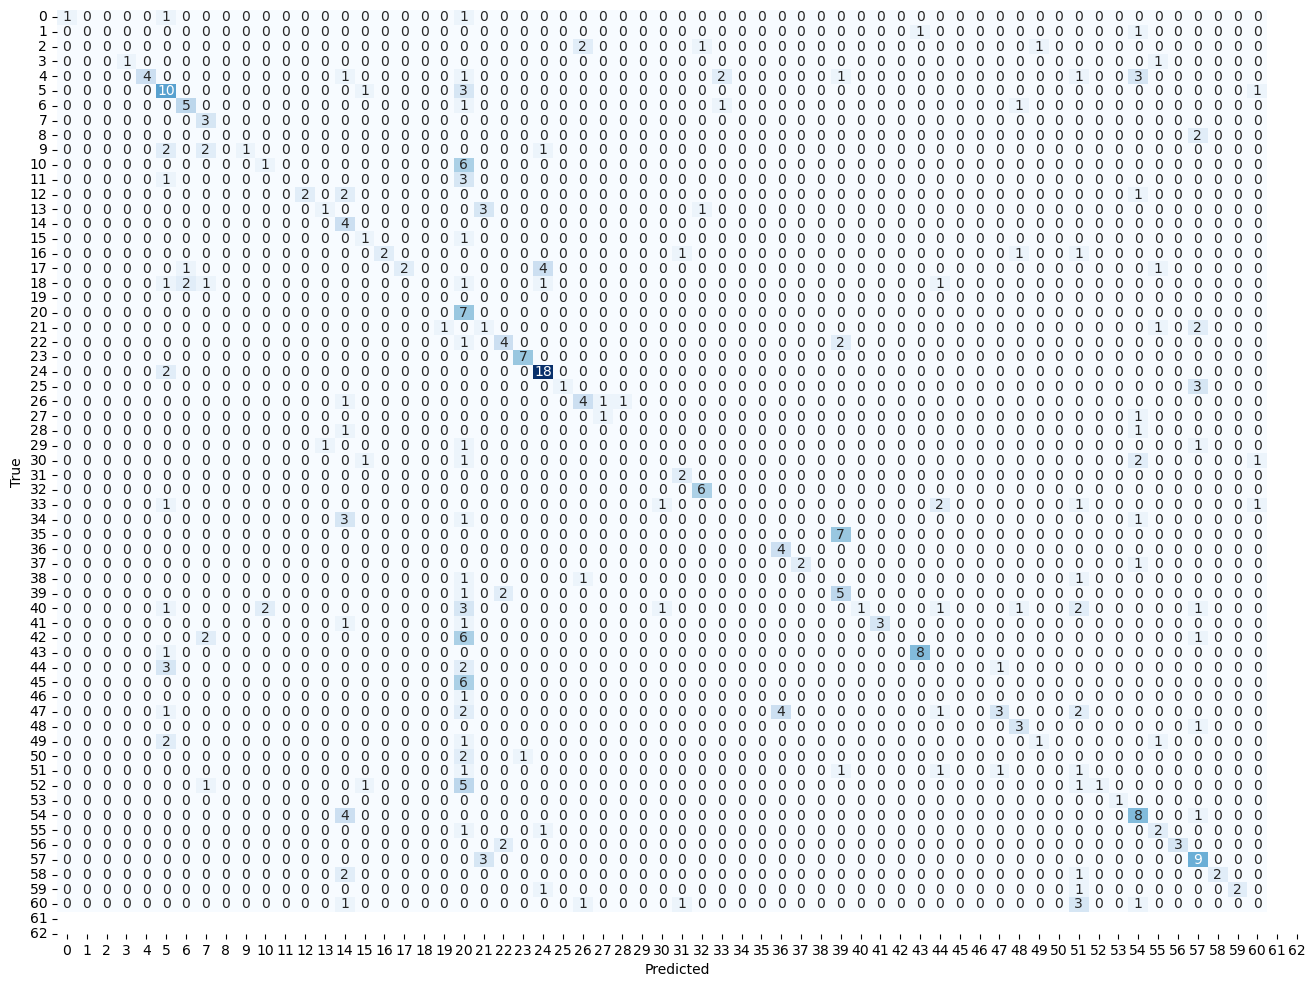

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(conf_matrix.get(), annot=True, fmt='d', cmap="Blues", cbar=False,
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [9]:
from cuml.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import StratifiedKFold

clf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy']
}

In [10]:
%%time
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid,
                           cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), n_jobs=-1)

grid_search.fit(X_train.to_numpy(), y_train.to_numpy())
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

CPU times: user 21 s, sys: 6.65 s, total: 27.7 s
Wall time: 1h 26min 38s


KeyboardInterrupt: 